In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/DELTA_Project/Data/archive.zip'
extract_path = '/content/drive/MyDrive/DELTA_Project/Data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:")
for f in os.listdir(extract_path):
    print(f)

Extracted files:
dynamic_api_call_sequence_per_malware_100_0_306.csv
archive.zip


In [7]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/DELTA_Project/Data/dynamic_api_call_sequence_per_malware_100_0_306.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())

(43876, 102)
                               hash  t_0  t_1  t_2  t_3  t_4  t_5  t_6  t_7  \
0  071e8c3f8922e186e57548cd4c703a5d  112  274  158  215  274  158  215  298   
1  33f8e6d08a6aae939f25a8e0d63dd523   82  208  187  208  172  117  172  117   
2  b68abd064e975e1c6d5f25e748663076   16  110  240  117  240  117  240  117   
3  72049be7bd30ea61297ea624ae198067   82  208  187  208  172  117  172  117   
4  c9b3700a77facf29172f32df6bc77f48   82  240  117  240  117  240  117  240   

   t_8  ...  t_91  t_92  t_93  t_94  t_95  t_96  t_97  t_98  t_99  malware  
0   76  ...    71   297   135   171   215    35   208    56    71        1  
1  172  ...    81   240   117    71   297   135   171   215    35        1  
2  240  ...    65   112   123    65   112   123    65   113   112        1  
3  172  ...   208   302   208   302   187   208   302   228   302        1  
4  117  ...   209   260    40   209   260   141   260   141   260        1  

[5 rows x 102 columns]
['hash', 't_0', 't_1', 't_

In [8]:
# Check class distribution
print(df['malware'].value_counts())

malware
1    42797
0     1079
Name: count, dtype: int64


In [9]:
from sklearn.utils import resample

# Separate classes
df_malware = df[df['malware'] == 1]
df_benign = df[df['malware'] == 0]

# Oversample benign to match malware
df_benign_oversampled = resample(df_benign,
                                  replace=True,
                                  n_samples=len(df_malware),
                                  random_state=42)

# Combine
df_balanced = pd.concat([df_malware, df_benign_oversampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['malware'].value_counts())

malware
0    42797
1    42797
Name: count, dtype: int64


In [10]:
import numpy as np

# Seprate the features and labels
X = df_balanced.drop(['hash', 'malware'], axis=1).values
y = df_balanced['malware'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (85594, 100)
y shape: (85594,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (68475, 100)
X_test shape: (17119, 100)


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout

# Vocabulary size
vocab_size = int(X.max()) + 1

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=100),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 294s 158ms/step - accuracy: 0.9439 - loss: 0.1495 - val_accuracy: 0.9751 - val_loss: 0.0720
Epoch 2/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 320s 156ms/step - accuracy: 0.9852 - loss: 0.0475 - val_accuracy: 0.9881 - val_loss: 0.0425
Epoch 3/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 287s 158ms/step - accuracy: 0.9898 - loss: 0.0343 - val_accuracy: 0.9878 - val_loss: 0.0320
Epoch 4/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 289s 159ms/step - accuracy: 0.9918 - loss: 0.0274 - val_accuracy: 0.9938 - val_loss: 0.0265
Epoch 5/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 313s 154ms/step - accuracy: 0.9937 - loss: 0.0222 - val_accuracy: 0.9922 - val_loss: 0.0264
Epoch 6/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 337s 162ms/step - accuracy: 0.9945 - loss: 0.0198 - val_accuracy: 0.9949 - val_loss: 0.0224
Epoch 7/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 315s 173ms/step - accuracy: 0.9942 - loss: 0.0191 - val_accuracy: 0.9922 - val_loss: 0.0337
Epoch 8/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 288s 158ms/step - ac

535/535 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step


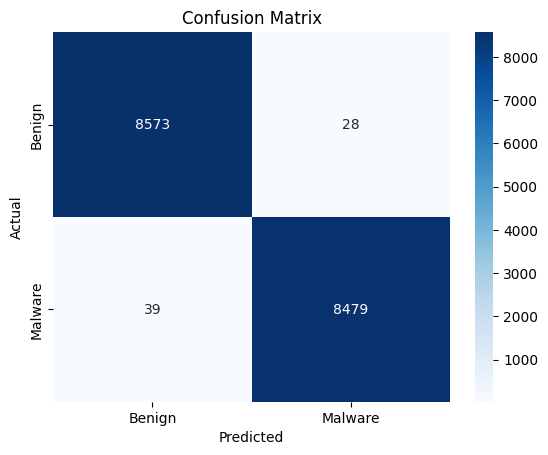

In [ ]:


from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'],
            cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout, Concatenate, GlobalMaxPooling1D

# Multi-kernel CNN + LSTM
input_layer = Input(shape=(100,))
embedding = Embedding(input_dim=vocab_size, output_dim=64)(input_layer)

# 3 parallel CNN with different kernel sizes
conv3 = Conv1D(64, kernel_size=3, activation='relu')(embedding)
conv5 = Conv1D(64, kernel_size=5, activation='relu')(embedding)
conv7 = Conv1D(64, kernel_size=7, activation='relu')(embedding)

# Global max pooling for each
pool3 = GlobalMaxPooling1D()(conv3)
pool5 = GlobalMaxPooling1D()(conv5)
pool7 = GlobalMaxPooling1D()(conv7)

# Concatenate all
merged = Concatenate()([pool3, pool5, pool7])

# Dense layers
dense = Dense(128, activation='relu')(merged)
dropout = Dropout(0.5)(dense)
output = Dense(1, activation='sigmoid')(dropout)

model2 = Model(inputs=input_layer, outputs=output)
model2.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

model2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 100, 64)   │     19,648 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 98, 64)    │     12,352 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 96, 64)    │     20,544 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 94, 64)    │     28,736 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_3[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     24,704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 106,113 (414.50 KB)

 Trainable params: 106,113 (414.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history2 = model2.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 98s 52ms/step - accuracy: 0.9731 - loss: 0.0752 - val_accuracy: 0.9899 - val_loss: 0.0430
Epoch 2/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 90s 49ms/step - accuracy: 0.9929 - loss: 0.0246 - val_accuracy: 0.9937 - val_loss: 0.0217
Epoch 3/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 89s 49ms/step - accuracy: 0.9940 - loss: 0.0214 - val_accuracy: 0.9946 - val_loss: 0.0239
Epoch 4/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 142s 49ms/step - accuracy: 0.9947 - loss: 0.0185 - val_accuracy: 0.9962 - val_loss: 0.0177
Epoch 5/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 88s 48ms/step - accuracy: 0.9942 - loss: 0.0189 - val_accuracy: 0.9947 - val_loss: 0.0189
Epoch 6/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 90s 49ms/step - accuracy: 0.9952 - loss: 0.0159 - val_accuracy: 0.9959 - val_loss: 0.0171
Epoch 7/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 90s 50ms/step - accuracy: 0.9949 - loss: 0.0177 - val_accuracy: 0.9942 - val_loss: 0.0210
Epoch 8/10
1819/1819 ━━━━━━━━━━━━━━━━━━━━ 89s 49ms/step - accuracy: 0.9952 

535/535 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step
=== Multi-Kernel CNN Results ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      8601
     Malware       1.00      1.00      1.00      8518

    accuracy                           1.00     17119
   macro avg       1.00      1.00      1.00     17119
weighted avg       1.00      1.00      1.00     17119



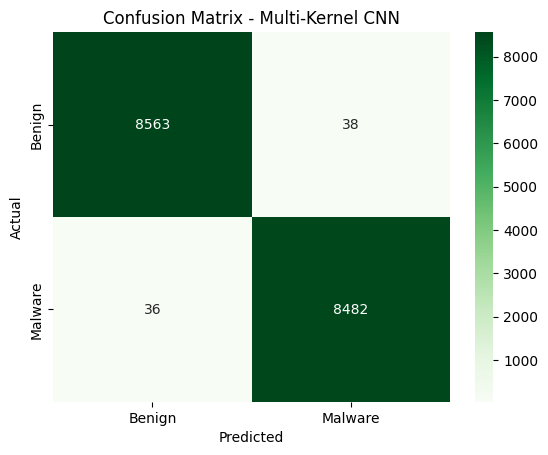

In [ ]:
y_pred2 = (model2.predict(X_test) > 0.5).astype(int)

print("=== Multi-Kernel CNN Results ===")
print(classification_report(y_test, y_pred2, target_names=['Benign', 'Malware']))

cm2 = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'],
            cmap='Greens')
plt.title('Confusion Matrix - Multi-Kernel CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Concatenate, Dense, Dropout

input_layer3 = Input(shape=(100,))
embedding3 = Embedding(input_dim=vocab_size, output_dim=64)(input_layer3)

# 5 parallel CNN branches with different kernel sizes
conv3 = Conv1D(64, kernel_size=3, activation='relu')(embedding3)
conv5 = Conv1D(64, kernel_size=5, activation='relu')(embedding3)
conv7 = Conv1D(64, kernel_size=7, activation='relu')(embedding3)
conv9 = Conv1D(64, kernel_size=9, activation='relu')(embedding3)
conv11 = Conv1D(64, kernel_size=11, activation='relu')(embedding3)

pool3 = GlobalMaxPooling1D()(conv3)
pool5 = GlobalMaxPooling1D()(conv5)
pool7 = GlobalMaxPooling1D()(conv7)
pool9 = GlobalMaxPooling1D()(conv9)
pool11 = GlobalMaxPooling1D()(conv11)

merged3 = Concatenate()([pool3, pool5, pool7, pool9, pool11])

dense3 = Dense(128, activation='relu')(merged3)
dropout3 = Dropout(0.5)(dense3)
output3 = Dense(1, activation='sigmoid')(dropout3)

model3 = Model(inputs=input_layer3, outputs=output3)
model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model3.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 100, 64)   │     19,648 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 98, 64)    │     12,352 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 96, 64)    │     20,544 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 94, 64)    │     28,736 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 92, 64)    │     36,928 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 90, 64)    │     45,120 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_4[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_5[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_6[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_7[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_8[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 320)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     41,088 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 204,545 (799.00 KB)

 Trainable params: 204,545 (799.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history3 = model3.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

In [ ]:
y_pred3 = (model3.predict(X_test) > 0.5).astype(int)

print("=== 5-Kernel CNN Results ===")
print(classification_report(y_test, y_pred3, target_names=['Benign', 'Malware']))

cm3 = confusion_matrix(y_test, y_pred3)
sns.heatmap(cm3, annot=True, fmt='d',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'],
            cmap='Oranges')
plt.title('Confusion Matrix - 5-Kernel CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Confusion matrix Model 1
plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'],
            cmap='Blues')
plt.title('Confusion Matrix - CNN+LSTM')
plt.savefig('/content/drive/MyDrive/DELTA_Project/cm1.png', dpi=300, bbox_inches='tight')

# Confusion matrix Model 2
plt.figure()
sns.heatmap(cm2, annot=True, fmt='d',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'],
            cmap='Greens')
plt.title('Confusion Matrix - 3-Kernel CNN')
plt.savefig('/content/drive/MyDrive/DELTA_Project/cm2.png', dpi=300, bbox_inches='tight')

# Confusion matrix Model 3
plt.figure()
sns.heatmap(cm3, annot=True, fmt='d',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'],
            cmap='Oranges')
plt.title('Confusion Matrix - 5-Kernel CNN')
plt.savefig('/content/drive/MyDrive/DELTA_Project/cm3.png', dpi=300, bbox_inches='tight')

# Early detection graph
plt.figure(figsize=(10,6))
plt.plot(windows, accuracies_m1, marker='o', color='blue', label='CNN+LSTM')
plt.plot(windows, accuracies_m3, marker='s', color='red', label='5-Kernel CNN')
plt.xlabel('Number of API Calls Observed')
plt.ylabel('Detection Accuracy (%)')
plt.title('Early Detection Analysis')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/DELTA_Project/early_detection.png', dpi=300, bbox_inches='tight')

print("All figures saved!")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model

# Models loading
model = load_model('/content/drive/MyDrive/DELTA_Project/model1_cnn_lstm.keras')
model2 = load_model('/content/drive/MyDrive/DELTA_Project/model2_3kernel.keras')
model3 = load_model('/content/drive/MyDrive/DELTA_Project/model3_5kernel.keras')

print("Models loaded!")

In [ ]:
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/drive/MyDrive/DELTA_Project/Data/dynamic_api_call_sequence_per_malware_100_0_306.csv')

df_malware = df[df['malware'] == 1]
df_benign = df[df['malware'] == 0]

df_benign_oversampled = resample(df_benign, replace=True, n_samples=len(df_malware), random_state=42)
df_balanced = pd.concat([df_malware, df_benign_oversampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X = df_balanced.drop(['hash', 'malware'], axis=1).values
y = df_balanced['malware'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data ready!")

In [ ]:
# Predictions
y_pred1 = (model.predict(X_test) > 0.5).astype(int)
y_pred2 = (model2.predict(X_test) > 0.5).astype(int)
y_pred3 = (model3.predict(X_test) > 0.5).astype(int)

# Confusion matrices save
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm1 = confusion_matrix(y_test, y_pred1)
sns.heatmap(cm1, annot=True, fmt='d', ax=axes[0],
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'], cmap='Blues')
axes[0].set_title('CNN-LSTM')

cm2 = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d', ax=axes[1],
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'], cmap='Greens')
axes[1].set_title('3-Kernel CNN')

cm3 = confusion_matrix(y_test, y_pred3)
sns.heatmap(cm3, annot=True, fmt='d', ax=axes[2],
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'], cmap='Oranges')
axes[2].set_title('5-Kernel CNN')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DELTA_Project/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")

In [ ]:
windows = [10, 20, 30, 50, 75, 100]
accuracies_m1 = []
accuracies_m3 = []

for w in windows:
    X_test_partial = np.copy(X_test)
    X_test_partial[:, w:] = 0

    y_pred_w1 = (model.predict(X_test_partial, verbose=0) > 0.5).astype(int)
    acc1 = (y_pred_w1.flatten() == y_test).mean() * 100
    accuracies_m1.append(acc1)

    y_pred_w3 = (model3.predict(X_test_partial, verbose=0) > 0.5).astype(int)
    acc3 = (y_pred_w3.flatten() == y_test).mean() * 100
    accuracies_m3.append(acc3)

plt.figure(figsize=(10, 6))
plt.plot(windows, accuracies_m1, marker='o', color='blue', linewidth=2, label='CNN+LSTM')
plt.plot(windows, accuracies_m3, marker='s', color='red', linewidth=2, label='5-Kernel CNN')
plt.xlabel('Number of API Calls Observed')
plt.ylabel('Detection Accuracy (%)')
plt.title('Early Detection Analysis')
plt.legend()
plt.grid(True)
plt.xticks(windows)
plt.savefig('/content/drive/MyDrive/DELTA_Project/early_detection.png', dpi=300, bbox_inches='tight')
plt.show()
print("Early detection graph saved!")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import zipfile
import os

# Unzip the new dataset
with zipfile.ZipFile('/content/drive/MyDrive/DELTA_Project/archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/DELTA_Project/Data2/')

print("Extracted!")
os.listdir('/content/drive/MyDrive/DELTA_Project/Data2/')

In [ ]:
import pandas as pd

df2 = pd.read_csv('/content/drive/MyDrive/DELTA_Project/Data2/new_dataset.csv')
print(df2.shape)
print(df2['malware'].value_counts())

In [ ]:
import pandas as pd
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

# Load dataset
df2 = pd.read_csv('/content/drive/MyDrive/DELTA_Project/Data2/new_dataset.csv')

# 100 Api calls
feature_cols = df2.columns[2:102]  # hash aur malware skip, pehle 100 tokens
X2 = df2[feature_cols].values
y2 = df2['malware'].values

# Oversample
df2_balanced = df2.copy()
df2_mal = df2[df2['malware']==1]
df2_ben = df2[df2['malware']==0]
df2_ben_over = resample(df2_ben, replace=True, n_samples=len(df2_mal), random_state=42)
df2_final = pd.concat([df2_mal, df2_ben_over]).sample(frac=1, random_state=42).reset_index(drop=True)

X2 = df2_final[feature_cols].values
y2 = df2_final['malware'].values

# Train test split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print(f"Dataset shape: {df2_final.shape}")
print(f"X2_train: {X2_train.shape} | X2_test: {X2_test.shape}")
print("Data ready!")

In [ ]:
import numpy as np

# Check NaN values
print(f"NaN values in X2: {np.isnan(X2).sum()}")

# Fill NaN with 0
X2 = np.nan_to_num(X2, nan=0).astype(int)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

vocab_size2 = int(X2.max()) + 1
print(f"New vocab size: {vocab_size2}")
print("Fixed!")

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Concatenate, Dense, Dropout

# Build 5-Kernel CNN for new dataset
input_layer_new = Input(shape=(100,))
embedding_new = Embedding(input_dim=vocab_size2, output_dim=64)(input_layer_new)

conv3n = Conv1D(64, kernel_size=3, activation='relu')(embedding_new)
conv5n = Conv1D(64, kernel_size=5, activation='relu')(embedding_new)
conv7n = Conv1D(64, kernel_size=7, activation='relu')(embedding_new)
conv9n = Conv1D(64, kernel_size=9, activation='relu')(embedding_new)
conv11n = Conv1D(64, kernel_size=11, activation='relu')(embedding_new)

pool3n = GlobalMaxPooling1D()(conv3n)
pool5n = GlobalMaxPooling1D()(conv5n)
pool7n = GlobalMaxPooling1D()(conv7n)
pool9n = GlobalMaxPooling1D()(conv9n)
pool11n = GlobalMaxPooling1D()(conv11n)

merged_new = Concatenate()([pool3n, pool5n, pool7n, pool9n, pool11n])
dense_new = Dense(128, activation='relu')(merged_new)
dropout_new = Dropout(0.5)(dense_new)
output_new = Dense(1, activation='sigmoid')(dropout_new)

model_new = Model(inputs=input_layer_new, outputs=output_new)
model_new.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train on new dataset
history_new = model_new.fit(
    X2_train, y2_train,
    epochs=15,
    batch_size=16,
    validation_split=0.15,
    verbose=1
)

In [ ]:
y2_pred_new = (model_new.predict(X2_test) > 0.5).astype(int)

print("=== 5-Kernel CNN Results on New Dataset ===")
print(classification_report(y2_test, y2_pred_new, target_names=['Benign', 'Malware']))

cm_new = confusion_matrix(y2_test, y2_pred_new)
sns.heatmap(cm_new, annot=True, fmt='d',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'],
            cmap='Purples')
plt.title('Confusion Matrix - 5-Kernel CNN (New Dataset)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import os
files = os.listdir('/content/drive/MyDrive/DELTA_Project/Data/')
print(files)
